# Five hypotheses about a one-party chamber
### Exploratory experiments on the LXVI roll-call (Chamber of Deputies, 2024–2027)

The companion case study showed two things about Mexico's current Chamber: every
caucus votes as a near-perfect bloc, and the six caucuses resolve into two stable
coalitions — a governing **MORENA · PVEM · PT** and an opposition **PRI · PAN · MC**.

That is the *structure*. This notebook pokes at the *behaviour* with five
hypotheses, each tested against the real warehouse — 274 recorded votes, 554
deputies, 136,947 individual ballots, every count reconciled to the chamber's own
official tallies. Some hypotheses survive contact with the data; some don't; one
can't be answered at all without capturing more, and the notebook says so plainly
rather than guessing.

> **Honesty note.** Two of the hypotheses ask *who initiated* a bill. The roll-call
> source records the vote, not the bill's author — that lives in a different system
> (SIL / Gaceta Parlamentaria). Where that bites, it is flagged, and a proxy is used
> in its place. No origin is ever invented.

In [1]:
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- brand palette (the portfolio design tokens) ---
INK, OX, OCHRE, FOREST, PAPER, GREY = '#1A1814', '#6E1F1F', '#A87333', '#2E4A3F', '#F4EFE6', '#6B655C'
plt.rcParams.update({
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'savefig.facecolor': PAPER,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.edgecolor': INK, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False,
})

def find_warehouse() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        c = base / '01_professional' / 'legislative-data-pipeline' / 'data' / 'legislative.duckdb'
        if c.exists():
            return c
    raise FileNotFoundError('warehouse not found — build the legislative pipeline first')

con = duckdb.connect(str(find_warehouse()), read_only=True)
print('warehouse:', find_warehouse())

warehouse: /Users/mariocasanova10pa/Documents/Portfolio/Portfolio-repo/01_professional/legislative-data-pipeline/data/legislative.duckdb


In [2]:
# Short caucus labels + the two coalitions (the conformed party comes from the
# dated dim_legislator; here we take each deputy's modal — most-held — caucus).
LONG2SHORT = {
    'Movimiento Regeneración Nacional': 'MORENA', 'Partido Acción Nacional': 'PAN',
    'Partido Verde Ecologista de México': 'PVEM', 'Partido del Trabajo': 'PT',
    'Partido Revolucionario Institucional': 'PRI', 'Movimiento Ciudadano': 'MC',
    'Independiente': 'IND',
}
BLOC = {'MORENA': 'gov', 'PVEM': 'gov', 'PT': 'gov',
        'PAN': 'opp', 'PRI': 'opp', 'MC': 'opp', 'IND': 'other', 'PRD': 'other'}
ORDER = ['MORENA', 'PVEM', 'PT', 'PRI', 'PAN', 'MC']

votes = con.execute('''
    select cast(vote_event_id as int) vid, legislator_id lid, vote_cast sense
    from main.fact_vote where legislature = 66
''').df()

dep = con.execute('''
    with modal as (
        select legislator_id, party,
               row_number() over (partition by legislator_id order by count(*) desc, party) rn
        from main.stg_sitl_votes group by 1, 2)
    select v.legislator_id as lid, min(v.full_name) as nm, any_value(m.party) as plong
    from main.stg_sitl_votes v
    join modal m on m.legislator_id = v.legislator_id and m.rn = 1
    group by 1
''').df()
dep = dep.rename(columns={'nm': 'name'})
dep['party'] = dep.plong.map(LONG2SHORT).fillna('IND')
dep['bloc'] = dep.party.map(BLOC)
dep = dep.set_index('lid')

vp = votes.copy()
vp['party'] = vp.lid.map(dep['party'])
vp['bloc'] = vp.party.map(BLOC)

# fast per-deputy lookup: vid -> {lid: sense}
sense_by = {vid: dict(zip(g.lid, g.sense)) for vid, g in vp.groupby('vid')}
print(f'{dep.shape[0]} deputies · {vp.vid.nunique()} votes · {len(vp):,} ballots')
vp.sense.value_counts()

554 deputies · 274 votes · 136,947 ballots


sense
FOR        108826
ABSENT      13685
AGAINST     13543
ABSTAIN       893
Name: count, dtype: int64

In [3]:
# Reduce every vote to a side per caucus and per bloc (majority of FOR vs AGAINST).
cnt = (vp[vp.sense.isin(['FOR', 'AGAINST'])]
       .groupby(['vid', 'party', 'sense']).size().unstack('sense', fill_value=0))
for c in ['FOR', 'AGAINST']:
    if c not in cnt.columns:
        cnt[c] = 0
cnt = cnt.reset_index()
cnt['pside'] = np.where(cnt.FOR > cnt.AGAINST, 'FOR',
               np.where(cnt.AGAINST > cnt.FOR, 'AGAINST', 'TIE'))
cnt['bloc'] = cnt.party.map(BLOC)

bl = cnt.groupby(['vid', 'bloc'])[['FOR', 'AGAINST']].sum().reset_index()
bl['side'] = np.where(bl.FOR > bl.AGAINST, 'FOR',
             np.where(bl.AGAINST > bl.FOR, 'AGAINST', 'TIE'))
sides = bl.pivot(index='vid', columns='bloc', values='side')
party_majority = cnt.set_index(['vid', 'party']).pside
sides.head()

bloc,gov,opp,other
vid,,,
2,FOR,AGAINST,NaN
3,FOR,AGAINST,NaN
4,FOR,FOR,FOR
5,FOR,FOR,NaN
7,FOR,AGAINST,FOR


## Experiment 1 — How often do the two blocs actually disagree?

**Hypotheses 1 & 2 (Mario):** *bills the opposition initiates get supported by the
government bloc; bills the government initiates get supported by the opposition.*

Both ask about **who authored** each bill — which the roll-call source does not
carry. What we *can* measure without inventing an origin is the observable shadow
of those hypotheses: on each vote, does the opposition bloc land on the **same
side** as the government bloc? A high rate of agreement is the footprint of
cross-aisle support, whoever wrote the text.

In [4]:
g, o = sides['gov'], sides['opp']
both_for     = int(((g == 'FOR') & (o == 'FOR')).sum())
both_against = int(((g == 'AGAINST') & (o == 'AGAINST')).sum())
divided      = int(((g != o) & (g != 'TIE') & (o != 'TIE')).sum())
gov_against  = int((g == 'AGAINST').sum())

divided_vids = set(sides.index[(g != o) & (g != 'TIE') & (o != 'TIE')])
N = len(sides)
print(f'Bipartisan  (both blocs FOR):     {both_for:3d}  ({100*both_for/N:.0f}%)')
print(f'Joint reject (both blocs AGAINST): {both_against:3d}')
print(f'Divided     (gov vs opp opposite): {divided:3d}  ({100*divided/N:.0f}%)')
print(f'Votes where the GOVERNMENT bloc was on the AGAINST side: {gov_against}')

Bipartisan  (both blocs FOR):     157  (57%)
Joint reject (both blocs AGAINST):   0
Divided     (gov vs opp opposite): 116  (42%)
Votes where the GOVERNMENT bloc was on the AGAINST side: 0


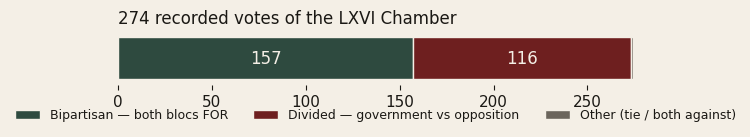

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 1.7))
seg = [('Bipartisan — both blocs FOR', both_for, FOREST),
       ('Divided — government vs opposition', divided, OX),
       ('Other (tie / both against)', N - both_for - divided, GREY)]
left = 0
for label, val, color in seg:
    ax.barh(0, val, left=left, color=color, edgecolor=PAPER)
    if val > 6:
        ax.text(left + val / 2, 0, str(val), ha='center', va='center', color=PAPER, fontsize=12)
    left += val
ax.set_xlim(0, N); ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.set_title('274 recorded votes of the LXVI Chamber', loc='left', fontsize=12, color=INK)
ax.legend([label for label, _, _ in seg], loc='upper center',
          bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**Reading.** A majority of votes — **157 of 274 (57%)** — are *bipartisan*: the
opposition bloc votes **for** the same measure the government does. The blocs are
genuinely opposed on only 116 (42%). And the government bloc is **never** on the
losing side: it sets the agenda, so essentially nothing reaches the floor that it
opposes (joint rejections: 0).

So the "two blocs" of the case study are real but they are not at war on every
vote — they clash **less than half the time**. What this *cannot* tell us is
Mario's actual question: of those 157 bipartisan bills, how many did the
**opposition** author and the government then back (H1), versus the reverse (H2).

> **Data gap.** Answering H1/H2 needs the **author / initiating group** of each bill,
> which is in the SIL (*Sistema de Información Legislativa*) and the Gaceta, keyed by
> *iniciativa*, not by *votación*. That is a separate capture — a clean next step,
> not something to fake from the vote titles (which carry no author: 0 of 274 name a
> proponent).

## Experiment 2 — Is absence used to dodge a vote?

**Hypothesis 3 (Mario):** *in Mexico it's common to not show up instead of voting
against — the no-show stands in for a "no".* If true, we'd expect **more** absence
on the contentious (divided) votes, where a recorded "no" is costly.

In [6]:
vp['contentious'] = vp.vid.isin(divided_vids)

# overall vote mix per caucus
mix = (vp.groupby('party').sense.value_counts(normalize=True)
       .unstack(fill_value=0) * 100).reindex(ORDER)[['FOR', 'AGAINST', 'ABSTAIN', 'ABSENT']]

# absence rate: contentious vs consensus
absr = (vp.assign(ab=vp.sense.eq('ABSENT'))
        .groupby(['party', 'contentious']).ab.mean().unstack() * 100)
absr = absr.rename(columns={False: 'consensus', True: 'contentious'}).reindex(ORDER)
absr['Δ (pp)'] = absr['contentious'] - absr['consensus']
print('Vote mix by caucus (%):'); print(mix.round(1)); print()
print('Absence rate, contentious vs consensus (%):'); print(absr.round(1))

Vote mix by caucus (%):
sense    FOR  AGAINST  ABSTAIN  ABSENT
party                                 
MORENA  90.2      0.1      0.1     9.6
PVEM    90.2      0.3      0.0     9.5
PT      87.6      1.0      0.7    10.7
PRI     50.0     37.8      2.0    10.2
PAN     50.1     36.7      2.0    11.2
MC      56.8     31.7      1.8     9.7

Absence rate, contentious vs consensus (%):
contentious  consensus  contentious  Δ (pp)
party                                      
MORENA            10.8          8.0    -2.9
PVEM               9.8          9.0    -0.8
PT                12.0          8.8    -3.2
PRI               11.9          7.9    -4.0
PAN               12.0         10.1    -1.9
MC                11.4          7.5    -4.0


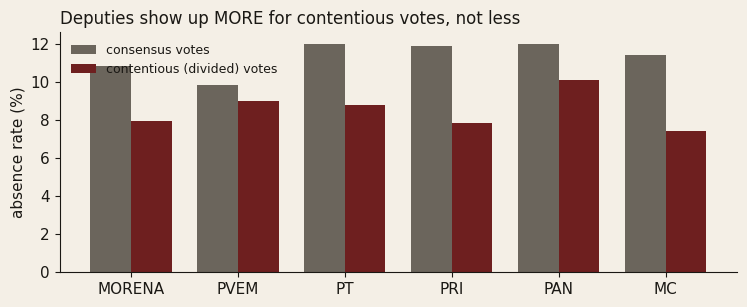

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 3.2))
x = np.arange(len(ORDER)); w = 0.38
ax.bar(x - w/2, absr['consensus'], w, label='consensus votes', color=GREY)
ax.bar(x + w/2, absr['contentious'], w, label='contentious (divided) votes', color=OX)
ax.set_xticks(x); ax.set_xticklabels(ORDER)
ax.set_ylabel('absence rate (%)')
ax.set_title('Deputies show up MORE for contentious votes, not less', loc='left', fontsize=12)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**The hypothesis is rejected — and the data points the other way.** For *every*
caucus, absence is **higher on the routine consensus votes** than on the contentious
ones (Δ between −0.7 and −3.9 points). When the blocs actually split, deputies turn
up; it's the unanimous procedural decretos they skip.

Two more corrections to the folk model:

- **Abstention is not the escape hatch.** It's nearly non-existent — under 2% for
  every caucus. The real "non-vote" is recorded as **absent**, not abstain.
- **The opposition votes "no" openly.** PAN, PRI and MC each cast an explicit
  *against* on 31–38% of their ballots. They are not hiding a "no" behind absence —
  they put it on the record.

## Experiment 3 — Does the floor leader move with the party, or the party with the leader?

**Hypothesis 5 (Mario):** *correlation between the bancada leader and their party's
votes.* For each of the six *coordinadores*, we measure how often they land on their
own caucus's majority side. (Pearson correlation is degenerate here — government
leaders are near-constant "yes", zero variance — so the honest statistic is the
**agreement rate**, plus a look at who actually shows up.)

In [8]:
COORD = {'MORENA': 'monreal ávila', 'PAN': 'lixa', 'PRI': 'moreira valdez',
         'PVEM': 'puente salas', 'PT': 'sandoval flores', 'MC': 'ortega pacheco'}

def lid_for(party, key):
    sub = dep[(dep.party == party) & dep.name.str.lower().str.contains(key)]
    return sub.index[0]

rows = []
for party, key in COORD.items():
    lid = lid_for(party, key)
    agree = scored = cabs = ctot = 0
    for vid in sides.index:
        maj = party_majority.get((vid, party))
        cs = sense_by[vid].get(lid)
        ctot += 1
        cabs += (cs == 'ABSENT')
        if maj in ('FOR', 'AGAINST') and cs in ('FOR', 'AGAINST'):
            scored += 1; agree += (cs == maj)
    party_abs = vp[vp.party == party].sense.eq('ABSENT').mean() * 100
    rows.append([party, dep.loc[lid, 'name'], round(100*agree/scored, 1),
                 round(100*cabs/ctot, 1), round(party_abs, 1)])

coordf = pd.DataFrame(rows, columns=['party', 'coordinator', 'agree_%',
                                     'coord_absence_%', 'party_absence_%'])
coordf

,party,coordinator,agree_%,coord_absence_%,party_absence_%
0,MORENA,Monreal Ávila Ricardo,100.0,0.7,9.6
1,PAN,Lixa Abimerhi José Elías,100.0,0.0,11.2
2,PRI,Moreira Valdez Rubén Ignacio,100.0,0.7,10.2
3,PVEM,Puente Salas Carlos Alberto,100.0,3.6,9.5
4,PT,Sandoval Flores Reginaldo,99.6,11.3,10.7
5,MC,Ortega Pacheco Ivonne Aracelly,100.0,16.8,9.7


**Discipline is total — the interesting variance is in attendance.** Every
coordinator agrees with their caucus on **≥99.6%** of votes; the leader *is* the
line. So "correlation" is the wrong lens: there's no variance to correlate.

What *does* vary is who bothers to be present. The government and PRI/PAN leaders are
nearly always there (Monreal 0.7%, Lixa 0.0%, Moreira 0.7% absent). But the two
smaller opposition leaders are absent **more than their own rank-and-file**:
**Ivonne Ortega (MC) misses 16.8%** and **Reginaldo Sandoval (PT) 11.3%** — a quieter
story about which floor leaders actually work the floor.

## Experiment 4 — Do the media rivals vote like rivals?

**Hypothesis 4 (Mario):** *take the media-prominent deputies and see how they vote
against the opponents they argue with on TV.* A hand-picked set (swap freely — this
is the subjective one); the cell prints a same-side agreement matrix.

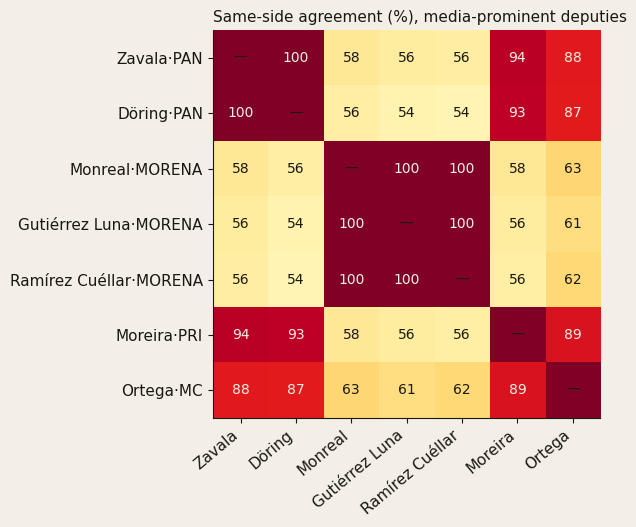

In [9]:
MEDIA = {
    'Zavala·PAN': 'zavala gómez', 'Döring·PAN': 'döring',
    'Monreal·MORENA': 'monreal ávila', 'Gutiérrez Luna·MORENA': 'gutiérrez luna',
    'Ramírez Cuéllar·MORENA': 'ramírez cuéllar', 'Moreira·PRI': 'moreira valdez',
    'Ortega·MC': 'ortega pacheco',
}
mlabels = list(MEDIA)
mlids = [dep[dep.name.str.lower().str.contains(k)].index[0] for k in MEDIA.values()]

def same_side(a, b):
    bo = sa = 0
    for vid in sides.index:
        x, y = sense_by[vid].get(a), sense_by[vid].get(b)
        if x in ('FOR', 'AGAINST') and y in ('FOR', 'AGAINST'):
            bo += 1; sa += (x == y)
    return 100 * sa / bo if bo else np.nan

M = np.array([[same_side(a, b) for b in mlids] for a in mlids])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(M, cmap='YlOrRd', vmin=50, vmax=100)
ax.set_xticks(range(len(mlabels))); ax.set_yticks(range(len(mlabels)))
ax.set_xticklabels([l.split('·')[0] for l in mlabels], rotation=40, ha='right')
ax.set_yticklabels(mlabels)
for i in range(len(mlabels)):
    for j in range(len(mlabels)):
        v = M[i, j]
        ax.text(j, i, '—' if i == j else f'{v:.0f}', ha='center', va='center',
                color=(PAPER if (i != j and v > 78) else INK), fontsize=10)
ax.set_title('Same-side agreement (%), media-prominent deputies', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

In [10]:
# Who actually crosses? Opposition deputies most likely to vote WITH the government
# on the divided votes where the government bloc went FOR.
gov_for_divided = [vid for vid in divided_vids if sides.loc[vid, 'gov'] == 'FOR']
rows = []
for lid, r in dep[dep.bloc == 'opp'].iterrows():
    wg = n = 0
    for vid in gov_for_divided:
        s = sense_by[vid].get(lid)
        if s in ('FOR', 'AGAINST'):
            n += 1; wg += (s == 'FOR')
    if n >= 20:
        rows.append([r['name'], r.party, round(100*wg/n), n])
mav = (pd.DataFrame(rows, columns=['deputy', 'party', 'with_gov_%', 'divided_votes'])
       .sort_values('with_gov_%', ascending=False).head(8).reset_index(drop=True))
mav

,deputy,party,with_gov_%,divided_votes
0,Gaona Domínguez Eduardo,MC,25,53
1,Mercado Castro Patricia,MC,23,110
2,Ruiz Hernández Juan Armando,MC,22,110
3,Samperio Montaño Juan Ignacio,MC,22,92
4,Longoria López Paola Michell,MC,22,107
5,Ortega Pacheco Ivonne Aracelly,MC,22,104
6,González Franco Amancay,MC,22,102
7,De Hoyos Walther Gustavo Adolfo,MC,21,92


**The blocs reproduce themselves at the individual level.** Within a caucus the
media figures are identical (Zavala–Döring 100%, the three MORENA names 100%); across
the aisle they fall to the mid-50s — exactly the coalition gap from the case study,
now with faces on it. The PRI's Moreira sits with PAN (93–94%); MC's Ortega is the
*softest* opposition, closer to the government than PAN is.

And the deputies who cross the floor most often are **all from Movimiento Ciudadano**
— though even the biggest "maverick" only sides with the government on ~a quarter of
the contested votes. MC is the hinge, but a reluctant one.

## Experiment 5 — Could the opposition ever have won on the floor?

**Hypothesis 6 (mine — this one wasn't on the original list).** Experiment 4 called
Movimiento Ciudadano "the hinge": the caucus most willing to break from the rest of
the opposition and land with the government. A hinge is supposed to swing something.
Reading that result, I expected its mirror to hold too — that on at least a few of
these 274 votes, tight enough for MC's roughly-one-in-four defection rate to matter,
the crossover was *load-bearing*: the difference between a bill passing and failing.

So: take the government bloc's own FOR count, alone, on each vote, and compare it
against the worst case for the government — every other deputy present, opposition
or otherwise, voting AGAINST. If that worst case still clears, no crossover from
anyone, in either direction, was ever needed.

In [11]:
gov_for = vp[(vp.bloc == 'gov') & (vp.sense == 'FOR')].groupby('vid').size().reindex(sides.index, fill_value=0)
total_against = vp[vp.sense == 'AGAINST'].groupby('vid').size().reindex(sides.index, fill_value=0)
margin = gov_for - total_against

print(f'Votes where gov FOR alone beats the worst-case AGAINST: {int((margin > 0).sum())} / {len(margin)}')
print(margin.describe().round(1))
print(f'Tightest margin observed: {int(margin.min())} votes (vote {margin.idxmin()})')

Votes where gov FOR alone beats the worst-case AGAINST: 274 / 274
count    274.0
mean     277.4
std       57.0
min       25.0
25%      221.0
50%      302.0
75%      325.0
max      360.0
dtype: float64
Tightest margin observed: 25 votes (vote 242)


**It never was — not once.** The government bloc's own FOR count beats the
worst-case AGAINST on **all 274 votes**, with a median cushion of 302 ballots and a
minimum of 25 on the single tightest vote of the term. There is no vote in this
legislature where the opposition's unity, MC's defections, or anyone crossing the
aisle in either direction could have changed the outcome — the arithmetic was
settled the day the coalition was sworn in, before a single one of the 274 debates
happened.

That reframes Experiment 4 more than it extends it. MC is not a "reluctant hinge" —
a hinge, even a stiff one, still turns something. Structurally, nothing turned. Its
crossover votes are a real, measurable behavioural signature (Experiment 4 isn't
wrong about that); they're just never a *consequential* one.

> **Scope note.** This uses the ordinary (simple) majority rule — FOR beats AGAINST
> — the same rule Experiment 1 uses to score sides. The warehouse carries a
> `requires_qualified` flag for constitutional (two-thirds) votes, but only for
> legislatures 60–61; it isn't populated for the LXVI (66th) roll-call yet, so I
> can't split out any vote here that may have needed a supermajority instead. For
> reference, the government bloc is ~72% of the 554 deputies ever recorded this
> term — above the two-thirds line on paper, but nowhere near the 25-vote-minimum
> cushion found here for ordinary majorities. Worth re-running once that flag
> exists for leg. 66.
>
> This isn't a hypothetical gap. Vote 242 (this experiment's tightest, margin
> +25) is a real, named vote: the 11 March 2026 constitutional reform reducing
> plurinominal (party-list) seats from 200 to 100. It clears the ordinary-majority
> arithmetic above (259 to 234). It needed a two-thirds, 334-vote threshold to
> actually amend the constitution, and didn't get one — the Chamber rejected it.
> Experiment 6 picks this vote back up.

## Experiment 6 — Do the junior coalition partners hold real veto power?

**Hypothesis 7 (also mine, it follows from Experiment 5, not from the original
list).** The government bloc's floor safety margin never fails. But that bloc is
three parties, not one, and MORENA is by far the largest. If a party agrees to run
fewer of its own candidates and share districts with a bigger ally in exchange for
a guaranteed bloc of seats, it is trading numbers for leverage: it becomes too
small to ever win alone, but potentially large enough to be missed. So: is
MORENA's own headcount, by itself, already a working majority, or does the
government's comfortable margin in Experiment 5 actually belong to its allies?

I can't verify *how* PVEM and PT arrived at their specific seat share (which
districts each party ran, and on what terms) from a vote warehouse; that lives in
electoral/candidacy records (INE), a different system entirely. What the warehouse
can measure is the outcome: does MORENA alone clear the same worst-case bar the
full coalition cleared on all 274 votes?

In [12]:
morena_for = vp[(vp.party == 'MORENA') & (vp.sense == 'FOR')].groupby('vid').size().reindex(sides.index, fill_value=0)
total_for_or_against = vp[vp.sense.isin(['FOR', 'AGAINST'])].groupby('vid').size().reindex(sides.index, fill_value=0)
morena_margin = 2 * morena_for - total_for_or_against   # MORENA alone vs. everyone else, worst case

fails = morena_margin[morena_margin <= 0]
print(f'Votes MORENA alone would still clear worst case: {int((morena_margin > 0).sum())} / {len(morena_margin)}')
print(f'Votes MORENA alone would FAIL worst case: {len(fails)}')
print(morena_margin.describe().round(1))
print(f'Tightest: vote {morena_margin.idxmin()}, margin {int(morena_margin.min())}')

Votes MORENA alone would still clear worst case: 212 / 274
Votes MORENA alone would FAIL worst case: 62
count    274.0
mean       9.7
std       20.3
min      -63.0
25%        1.0
50%        7.0
75%       13.0
max      145.0
dtype: float64
Tightest: vote 88, margin -63


In [13]:
bipartisan_vids = set(sides.index[(sides['gov'] == 'FOR') & (sides['opp'] == 'FOR')])
fail_vids = set(fails.index)
print(f'Of the {len(fail_vids)} votes MORENA fails alone: '
      f'{len(fail_vids & divided_vids)} are contested (divided), '
      f'{len(fail_vids & bipartisan_vids)} are bipartisan consensus votes.')

roster = dep['party'].value_counts()
print(f"Roster: MORENA {roster['MORENA']} ({100*roster['MORENA']/len(dep):.1f}%), "
      f"PVEM {roster['PVEM']} ({100*roster['PVEM']/len(dep):.1f}%), "
      f"PT {roster['PT']} ({100*roster['PT']/len(dep):.1f}%), of {len(dep)} total.")

Of the 62 votes MORENA fails alone: 24 are contested (divided), 38 are bipartisan consensus votes.
Roster: MORENA 278 (50.2%), PVEM 70 (12.6%), PT 51 (9.2%), of 554 total.


**It doesn't — not on nearly a quarter of the term's votes.** MORENA's own FOR
count fails the worst-case bar on **62 of 274 votes (23%)**, and on its single
worst vote of the term the shortfall runs to 63. And the shortfall isn't confined
to contested politics: 38 of those 62 votes are ones the *entire chamber*,
opposition included, ultimately voted for. MORENA needed its allies' headcount
even to pass bills nobody was fighting.

MORENA's own roster is 278 of the 554 deputies ever recorded this term, 50.2%, a
bare majority on paper before a single vote is cast. PVEM (70, 12.6%) and PT (51,
9.2%) supply the other 21.8 points that turn that thin majority into the
72%-of-the-roster supermajority Experiment 5 tested.

That's the *capacity* for a veto. Vote 242 is where it stopped being hypothetical.

In [14]:
v242 = vp[vp.vid == 242]
print(v242.groupby(['party', 'sense']).size().unstack(fill_value=0))

sense   ABSENT  ABSTAIN  AGAINST  FOR
party                                
IND          0        0        1    0
MC           0        0       28    0
MORENA       4        0        3  246
PAN          0        0       70    0
PRI          1        0       36    0
PT           1        0       47    1
PVEM         0        1       49   12


Vote 242, 11 March 2026: President Sheinbaum's constitutional reform to cut
plurinominal (party-list) seats in the Chamber from 200 to 100 (the same vote
Experiment 5 flagged as the term's tightest, and the one whose margin flips
negative for MORENA alone). The breakdown above is real, on the record: **MORENA
246 FOR, 3 AGAINST; PVEM 12 FOR, 49 AGAINST; PT 1 FOR, 47 AGAINST.** MORENA's
own coalition partners supplied 96 of the 234 votes against their own
government's flagship proposal. Total: 259 FOR against 234 AGAINST, short of
the 334 a constitutional amendment needs. Rejected.

The self-interest is not subtle. Plurinominal seats are how a party with modest
district-level support still holds a bloc in the Chamber; PVEM and PT get most
of their seats that way, MORENA mostly doesn't. Halving the list from 200 to 100
would have cost the allies far more than it would have cost MORENA. Ricardo
Monreal (MORENA's own floor coordinator, scored at 100% agreement with his
caucus in Experiment 3) spent the weeks before the vote publicly acknowledging
the reform was being renegotiated with PT and PVEM because it would not pass
without them. It didn't pass, and they're why.

So the honest version of Experiment 6 is not "PVEM and PT hold a veto they've
never used." It's narrower and more interesting: on the 273 votes that don't
touch their own seats, they vote with the government as disciplined as anyone in
this chamber (Rice index above 0.99, same as the companion piece already found).
On the one vote that did touch their own seats, discipline stopped, the veto
capacity from Experiment 6's own headcount test converted into an actual veto,
and the government's flagship reform of the term failed.

> **Scope note.** How PVEM and PT arrived at this specific seat share (coalition
> registration, which districts each party ran, on what terms) still sits in
> INE's electoral records, not in this vote warehouse; that half of the story is
> unverified here. What vote 242 verifies is the *use* of the resulting leverage,
> not its origin.

## What survived, what didn't, what's next

| # | Hypothesis | Verdict |
|---|---|---|
| 1 | Opposition-initiated bills get government support | **Unanswerable as-is** — needs bill authorship (SIL). Proxy: 57% of votes are bipartisan. |
| 2 | Government-initiated bills get opposition support | **Unanswerable as-is** — same gap. |
| 3 | Absence substitutes for a "no" vote | **Rejected** — absence is *higher* on consensus votes; abstention ≈ 0; the opposition votes "no" openly. |
| 4 | Media rivals vote as rivals | **Confirmed** — two blocs at the individual level; MC the soft hinge. |
| 5 | Floor leader correlates with the party | **Confirmed (degenerate)** — ≥99.6% agreement; the real variance is attendance (Ortega, Sandoval). |
| 6 | The opposition's crossovers (MC especially) were sometimes decisive | **Rejected** — the government bloc's own FOR count beats the worst-case AGAINST on all 274 votes; no crossover, from anyone, ever changed an outcome. |
| 7 | PVEM and PT are decorative allies, not structurally necessary | **Rejected, decisively** — MORENA's own headcount fails the same worst-case bar on 62 of 274 votes, and on the one vote that touched the allies' own seats (the March 2026 plurinominal reform), the latent veto was actually used: PVEM and PT supplied 96 of the 234 votes that sank it. |

Seven hypotheses in, one thing hasn't moved: everything genuinely contested about
how this Chamber votes is upstream of the vote itself — in who won the 2024
election and how the seats fell, not in what happens on the floor afterward.
Five, Six and Seven say the same thing from three angles, and vote 242 is where
all three meet: bloc discipline (Experiment 3) means there's no individual
defection worth looking for, bloc arithmetic (Experiment 5) means opposition
unity wouldn't have mattered even if it existed, and the bloc itself
(Experiment 6) turns out to be a coalition whose largest member needs its
allies — and on the one vote where the allies' own interests were at stake, that
need went unmet. The one genuinely new capture worth doing is still
**bill authorship** from the SIL: it would turn the 57% bipartisan figure into the
actual test of H1 and H2, *who proposes what the other side ends up backing.*
Everything else here is already answered, on real votes, reconciled to the official
tallies.